# LightGBM Score Calibration

This notebook calibrates the frozen engineered LightGBM model without retraining its trees.

The original 30-minute validation period is divided chronologically:

- **Calibration period:** 14:30 to 14:45
- **Calibration evaluation period:** 14:45 to 15:00

A simple sigmoid (Platt) calibrator is fitted on the earlier period. The 80%-recall threshold is also selected there, then both calibration quality and classification performance are checked on the later period.

> `is_attributed = 1` means an attributed app installation. It is not a confirmed non-fraud label.

## 1. Imports and settings

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import __version__ as sklearn_version
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "development_features.parquet"
MODEL_PATH = PROJECT_ROOT / "models" / "final_lightgbm_model.joblib"
METADATA_PATH = PROJECT_ROOT / "models" / "final_lightgbm_metadata.json"
CALIBRATOR_PATH = PROJECT_ROOT / "models" / "score_calibrator.joblib"
CALIBRATED_METADATA_PATH = PROJECT_ROOT / "models" / "final_calibrated_metadata.json"

TARGET = "is_attributed"
TIME_COLUMN = "click_time"
CALIBRATION_START = pd.Timestamp("2017-11-07 14:30:00")
EVALUATION_START = pd.Timestamp("2017-11-07 14:45:00")
EVALUATION_END = pd.Timestamp("2017-11-07 15:00:00")
TARGET_RECALL = 0.80
RANDOM_STATE = 42

## 2. Load and validate the frozen model, metadata and data

In [ ]:
for path in [DATA_PATH, MODEL_PATH, METADATA_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")

model = joblib.load(MODEL_PATH)
with METADATA_PATH.open(encoding="utf-8") as file:
    base_metadata = json.load(file)

features = base_metadata["features"]

if base_metadata.get("model_name") != "Engineered LightGBM":
    raise ValueError("The saved model metadata is not for Engineered LightGBM.")
if len(features) != 16:
    raise ValueError(f"Expected 16 model features, found {len(features)}.")

df = pd.read_parquet(DATA_PATH)

required_columns = set(features + [TIME_COLUMN, TARGET])
missing_columns = sorted(required_columns - set(df.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not pd.api.types.is_datetime64_any_dtype(df[TIME_COLUMN]):
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], errors="raise")
if df[TARGET].isna().any() or not set(df[TARGET].unique()).issubset({0, 1}):
    raise ValueError(f"{TARGET} must contain only 0 and 1 with no missing values.")
if df[features].isna().any().any():
    raise ValueError("Missing model feature values were found.")

print("Inputs validated successfully.")
print(f"Model: {base_metadata['model_name']}")
print(f"Features: {len(features)}")
print(f"Original operational threshold: {base_metadata['decision_threshold']:.6f}")

Inputs validated successfully.
Model: Engineered LightGBM
Features: 16
Original operational threshold: 0.954368


## 3. Create chronological calibration and evaluation sets

The later evaluation period is not used to fit the calibrator or select its threshold.

In [ ]:
calibration_mask = (
    (df[TIME_COLUMN] >= CALIBRATION_START)
    & (df[TIME_COLUMN] < EVALUATION_START)
)

evaluation_mask = (
    (df[TIME_COLUMN] >= EVALUATION_START)
    & (df[TIME_COLUMN] < EVALUATION_END)
)

X_calibration = df.loc[calibration_mask, features]
y_calibration = df.loc[calibration_mask, TARGET]
X_evaluation = df.loc[evaluation_mask, features]
y_evaluation = df.loc[evaluation_mask, TARGET]

if y_calibration.nunique() != 2 or y_evaluation.nunique() != 2:
    raise ValueError("Both chronological periods must contain both target classes.")

split_summary = pd.DataFrame(
    {
    "rows": [len(y_calibration), len(y_evaluation)],
    "attributed_clicks": [int(y_calibration.sum()), int(y_evaluation.sum())],
    "attribution_rate_percent": [y_calibration.mean() * 100, y_evaluation.mean() * 100],
    }, 
    index=["Calibration", "Evaluation"]
)

display(split_summary.style.format({
    "rows": "{:,.0f}",
    "attributed_clicks": "{:,.0f}",
    "attribution_rate_percent": "{:.6f}%",
}))

,rows,attributed_clicks,attribution_rate_percent
Calibration,"777,551","1,653",0.212591%
Evaluation,"753,367","1,433",0.190213%


## 4. Generate raw LightGBM scores

The fitted LightGBM remains unchanged. It only generates the one-dimensional score used by the calibrator.

In [4]:
raw_calibration_scores = model.predict_proba(X_calibration)[:, 1]
raw_evaluation_scores = model.predict_proba(X_evaluation)[:, 1]

print("Raw score summary — calibration period")
display(pd.Series(raw_calibration_scores).describe().to_frame("score"))

Raw score summary — calibration period


,score
count,"777,551.000000"
mean,0.036490
std,0.115531
min,0.000005
25%,0.000683
50%,0.003545
75%,0.018713
max,0.999828


## 5. Fit the sigmoid calibrator

Logistic regression learns a simple monotonic mapping from the weighted LightGBM score to observed attribution probability.

In [ ]:
calibrator = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

calibrator.fit(raw_calibration_scores.reshape(-1, 1), y_calibration)

calibrated_calibration_scores = calibrator.predict_proba(
    raw_calibration_scores.reshape(-1, 1)
)[:, 1]
calibrated_evaluation_scores = calibrator.predict_proba(
    raw_evaluation_scores.reshape(-1, 1)
)[:, 1]

print("Sigmoid calibrator fitted.")

Sigmoid calibrator fitted.


## 6. Evaluate calibration quality

Lower Brier score and log loss indicate better probability estimates. PR-AUC measures ranking and should remain essentially unchanged after a monotonic sigmoid transformation.

In [ ]:
def probability_metrics(y_true, scores):
    return {
        "pr_auc": average_precision_score(y_true, scores),
        "brier_score": brier_score_loss(y_true, scores),
        "log_loss": log_loss(y_true, scores, labels=[0, 1]),
        "mean_score": float(np.mean(scores)),
        "actual_positive_rate": float(np.mean(y_true)),
    }

raw_probability_metrics = probability_metrics(y_evaluation, raw_evaluation_scores)

calibrated_probability_metrics = probability_metrics(
    y_evaluation, calibrated_evaluation_scores
)

calibration_comparison = pd.DataFrame(
    [raw_probability_metrics, calibrated_probability_metrics],
    index=["Raw LightGBM score", "Calibrated score"],
)
display(calibration_comparison.style.format("{:.8f}"))

calibration_accepted = (
    calibrated_probability_metrics["brier_score"]
    < raw_probability_metrics["brier_score"]
)
print(f"Calibration improved evaluation Brier score: {calibration_accepted}")

,pr_auc,brier_score,log_loss,mean_score,actual_positive_rate
Raw LightGBM score,0.54609185,0.01198701,0.05426860,0.03432517,0.00190213
Calibrated score,0.54609185,0.00147514,0.00581081,0.00196369,0.00190213


Calibration improved evaluation Brier score: True


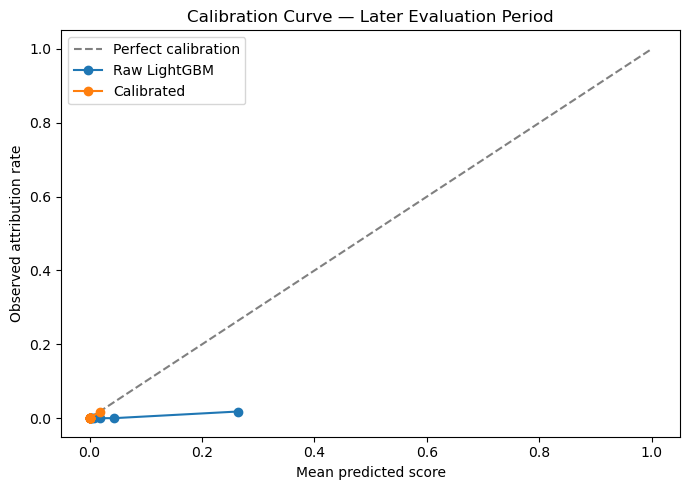

In [7]:
raw_fraction_positive, raw_mean_predicted = calibration_curve(
    y_evaluation, raw_evaluation_scores, n_bins=10, strategy="quantile"
)
cal_fraction_positive, cal_mean_predicted = calibration_curve(
    y_evaluation, calibrated_evaluation_scores, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.plot(raw_mean_predicted, raw_fraction_positive, marker="o", label="Raw LightGBM")
plt.plot(cal_mean_predicted, cal_fraction_positive, marker="o", label="Calibrated")
plt.xlabel("Mean predicted score")
plt.ylabel("Observed attribution rate")
plt.title("Calibration Curve — Later Evaluation Period")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Select the calibrated 80%-recall threshold

The threshold is selected using only the earlier calibration period. It is then applied unchanged to the later evaluation period.

In [8]:
cal_precision, cal_recall, cal_thresholds = precision_recall_curve(
    y_calibration, calibrated_calibration_scores
)
eligible_indexes = np.where(cal_recall[:-1] >= TARGET_RECALL)[0]
if len(eligible_indexes) == 0:
    raise ValueError(f"No calibrated threshold achieved {TARGET_RECALL:.0%} recall.")

threshold_index = eligible_indexes[
    np.argmax(cal_precision[:-1][eligible_indexes])
]
calibrated_threshold = float(cal_thresholds[threshold_index])

print(f"Calibrated threshold selected on earlier period: {calibrated_threshold:.8f}")
print(f"Calibration-period precision: {cal_precision[threshold_index]:.4%}")
print(f"Calibration-period recall: {cal_recall[threshold_index]:.4%}")

Calibrated threshold selected on earlier period: 0.18567327
Calibration-period precision: 26.0947%
Calibration-period recall: 80.0363%


## 8. Check the selected threshold on the later period

In [ ]:
def classification_metrics(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }

old_threshold = float(base_metadata["decision_threshold"])
raw_old_threshold_metrics = classification_metrics(
    y_evaluation, raw_evaluation_scores, old_threshold
)

calibrated_default_metrics = classification_metrics(
    y_evaluation, calibrated_evaluation_scores, 0.50
)

calibrated_operational_metrics = classification_metrics(
    y_evaluation, calibrated_evaluation_scores, calibrated_threshold
)

classification_comparison = pd.DataFrame(
    [
        raw_old_threshold_metrics,
        calibrated_default_metrics,
        calibrated_operational_metrics,
    ],
    index=[
        "Raw score — old threshold",
        "Calibrated score — threshold 0.50",
        "Calibrated score — selected threshold",
    ],
)

display(classification_comparison.style.format({
    "threshold": "{:.8f}",
    "accuracy": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "true_negatives": "{:,.0f}",
    "false_positives": "{:,.0f}",
    "false_negatives": "{:,.0f}",
    "true_positives": "{:,.0f}",
}))

,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
Raw score — old threshold,0.95436755,0.995521,0.272130,0.808793,0.407238,"748,834","3,100",274,"1,159"
Calibrated score — threshold 0.50,0.50000000,0.998098,0.000000,0.000000,0.000000,"751,934",0,"1,433",0
Calibrated score — selected threshold,0.18567327,0.995356,0.265866,0.818562,0.401369,"748,695","3,239",260,"1,173"


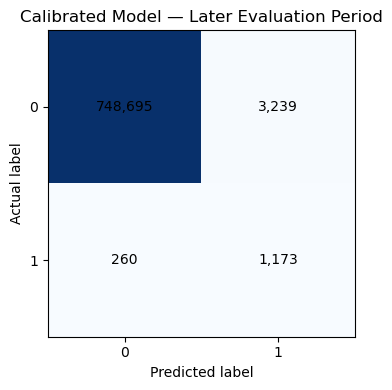

In [ ]:
# Confusion matrix of calibrated vs later evaluation period

evaluation_predictions = (
    calibrated_evaluation_scores >= calibrated_threshold
).astype(np.uint8)
evaluation_cm = confusion_matrix(y_evaluation, evaluation_predictions, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(evaluation_cm, cmap="Blues")
plt.title("Calibrated Model — Later Evaluation Period")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
for row in range(2):
    for column in range(2):
        plt.text(column, row, f"{evaluation_cm[row, column]:,}", ha="center", va="center")
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])
plt.tight_layout()
plt.show()

## 9. Save the calibrator and calibrated metadata

The fitted LightGBM file remains unchanged. The calibrator and its new threshold are saved separately. Saving is stopped automatically if calibration fails to improve the later-period Brier score.

In [11]:
if not calibration_accepted:
    raise RuntimeError(
        "Calibration did not improve evaluation Brier score. "
        "The calibrator was not saved."
    )

calibrated_metadata = {
    **base_metadata,
    "score_type": "sigmoid_calibrated_attribution_probability",
    "calibrator_type": "LogisticRegression Platt scaling",
    "calibration_start": CALIBRATION_START.isoformat(),
    "calibration_evaluation_start": EVALUATION_START.isoformat(),
    "calibration_evaluation_end": EVALUATION_END.isoformat(),
    "threshold_method": "selected_on_calibration_period_for_minimum_80_percent_recall",
    "decision_threshold": calibrated_threshold,
    "calibration_probability_metrics_raw": raw_probability_metrics,
    "calibration_probability_metrics_calibrated": calibrated_probability_metrics,
    "calibrated_validation_metrics": calibrated_operational_metrics,
    "calibration_accepted": calibration_accepted,
    "calibration_library_versions": {
        "scikit_learn": sklearn_version,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

joblib.dump(calibrator, CALIBRATOR_PATH)
with CALIBRATED_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(calibrated_metadata, file, indent=2)

print(f"Saved calibrator: {CALIBRATOR_PATH}")
print(f"Saved calibrated metadata: {CALIBRATED_METADATA_PATH}")
print("The original LightGBM model file was not modified.")

Saved calibrator: d:\Projects\Ad_Click_Fraud_Detection\models\score_calibrator.joblib
Saved calibrated metadata: d:\Projects\Ad_Click_Fraud_Detection\models\final_calibrated_metadata.json
The original LightGBM model file was not modified.


## 10. Inference example

The later application must apply the model, calibrator and calibrated threshold in this order.

In [12]:
# Example using the first five evaluation rows.
example_features = X_evaluation.iloc[:5]
example_raw_scores = model.predict_proba(example_features)[:, 1]
example_probabilities = calibrator.predict_proba(
    example_raw_scores.reshape(-1, 1)
)[:, 1]
example_predictions = (example_probabilities >= calibrated_threshold).astype(np.uint8)

display(pd.DataFrame({
    "raw_model_score": example_raw_scores,
    "calibrated_probability": example_probabilities,
    "prediction": example_predictions,
}))

,raw_model_score,calibrated_probability,prediction
0,0.100761,0.000286,0
1,0.000294,0.000130,0
2,0.131863,0.000366,0
3,0.000852,0.000131,0
4,0.005842,0.000136,0


## Interpretation and limitation

Calibration improves how model scores correspond to observed attribution rates; it does not improve the underlying ranking learned by LightGBM. The later evaluation period is separate from calibrator fitting and threshold selection, but it was part of the broader validation window previously used for LightGBM early stopping and model decisions. It is therefore a stronger calibration check, not a completely untouched final test. A later unseen time window remains the best optional final validation.